In [1]:
import json

import pandas as pd
import numpy as np
import ast
import os

from typing import Union, List

# Load Impact DF

In [2]:
def try_literal_eval(x):
    if isinstance(x, str):
        x = x.strip()
        if (x.startswith("[") and x.endswith("]")) or \
           (x.startswith("{") and x.endswith("}")) or \
           (x.startswith("(") and x.endswith(")")):
            try:
                return ast.literal_eval(x)
            except (ValueError, SyntaxError):
                return x
    return x

In [3]:
dataset_dir = "/home/yishin/keith/patent_research/model_io"

In [4]:
Impact_df = pd.read_csv(os.path.join(dataset_dir, "Impact_Sub_Complete.csv"), encoding="utf-8")
Impact_df = Impact_df.map(try_literal_eval)

Impact_df.head()

,title,caption,image_paths,best_fig_desc,Loc_class,main_class,sub_class,keywords,original_order,crop_paths
0,3D flower-shaped throw pillow,The image is a black and white drawing of a 3D...,[impact_dataset/2022/USD0954470-20220614/USD09...,{'FIG. 1': 'FIG. 1 is a front and top perspect...,{06-13},6,13,"[pillow, flower, stem, leaves]",342.0,[figure_crops/342_3D flower-shaped throw pillo...
1,3D printer extruder,The image is a black and white drawing of a 3D...,[impact_dataset/2022/USD0955471-20220621/USD09...,{'FIG. 1': 'FIG. 1 is a perspective view of a ...,{18-02},18,2,"[barrel, nozzle, element, heater]",2078.0,[figure_crops/2078_3D printer extruder/FIG_4.j...
2,3D wall panel,The image is a black and white geometric shape...,[impact_dataset/2022/USD0947417-20220329/USD09...,{'FIG. 1': 'FIG. 1 is a front and top elevatio...,{25-01},25,1,"[panel, shape, surface, room, design, element,...",2787.0,[figure_crops/2787_3D wall panel/FIG_3.jpg]
3,Absorber for a loudspeaker,"The image shows a round shape, which is a comm...",[impact_dataset/2022/USD0940115-20220104/USD09...,{'FIG. 2': 'FIG. 2 is a bottom perspective vie...,{14-01},14,1,"[round shape, material, absorber, loudspeaker]",1531.0,[figure_crops/1531_Absorber for a loudspeaker/...
4,Abutment holder for dental implants,The image is a black and white drawing of an A...,[impact_dataset/2022/USD0967427-20221018/USD09...,{'FIG. 1': 'FIG. 1 is a perspective view of an...,{24-03},24,3,"[cylinder, holder, abutment, grip, arm, base]",2749.0,[figure_crops/2749_Abutment holder for dental ...


In [7]:
Impact_df["crop_paths"].iloc[0]

['figure_crops/342_3D flower-shaped throw pillow/FIG_3.jpg',
 'figure_crops/342_3D flower-shaped throw pillow/FIG_4.jpg']

# SAM

## Detect Region Cells

In [8]:
import os
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from tqdm import tqdm

In [9]:
from transformers import pipeline
import numpy as np
import cv2

mask_generator = pipeline(
    "mask-generation",
    model="facebook/sam-vit-huge",
    device="cuda"
)

def get_sam_cells(image_path, points_per_side=32, min_mask_area=2000, max_mask_area_pct=0.7):
    img = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(image_rgb)
    h, w = image_rgb.shape[:2]
    total_area = h * w

    outputs = mask_generator(pil_image, points_per_side=points_per_side)

    grid_cells = []
    for i, mask in enumerate(outputs["masks"]):
        mask_np = np.array(mask)
        area = mask_np.sum()

        if area < min_mask_area:
            continue
        if area > total_area * max_mask_area_pct:   # skip overly large masks
            continue

        ys, xs = np.where(mask_np > 0)
        x1, y1, x2, y2 = int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())

        grid_cells.append({
            "id": len(grid_cells),
            "row": 0,
            "col": len(grid_cells),
            "bbox": (x1, y1, x2, y2),
            "mask": mask_np,
            "confidence_score": 1.0
        })

    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 80, 150)

    return image_rgb, grid_cells, edges

/home/yishin/miniconda3/envs/patent/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
def deduplicate_masks(grid_cells, iou_threshold=0.7):
    def compute_iou(a, b):
        ax1, ay1, ax2, ay2 = a["bbox"]
        bx1, by1, bx2, by2 = b["bbox"]
        ix1, iy1 = max(ax1, bx1), max(ay1, by1)
        ix2, iy2 = min(ax2, bx2), min(ay2, by2)
        if ix1 >= ix2 or iy1 >= iy2:
            return 0.0
        inter = (ix2 - ix1) * (iy2 - iy1)
        area_a = (ax2 - ax1) * (ay2 - ay1)
        area_b = (bx2 - bx1) * (by2 - by1)
        return inter / (area_a + area_b - inter)

    kept = []
    for cell in sorted(grid_cells, key=lambda c: c["mask"].sum(), reverse=True):
        if not any(compute_iou(cell, k) > iou_threshold for k in kept):
            kept.append(cell)
    return kept

In [11]:
def draw_grid_cells(image_rgb, grid_cells):
    img = Image.fromarray(image_rgb)
    output = img.copy()
    draw = ImageDraw.Draw(output)

    for cell in grid_cells:
        x1, y1, x2, y2 = cell["bbox"]

        draw.rectangle(
            (x1, y1, x2, y2),
            outline=(255, 0, 0),
            width=3
        )

    return output

In [12]:
def get_fig_id(image_path):
    return os.path.splitext(os.path.basename(image_path))[0]

In [13]:
def make_json_safe_region(cell):
    """
    Keep bbox and metadata, but do not store full mask array in the DataFrame.
    Store mask area instead.
    """
    return {
        "id": int(cell["id"]),
        "bbox": tuple(map(int, cell["bbox"])),
        "area": int(cell["mask"].sum()) if "mask" in cell else None
    }

In [18]:
def generate_sam_regions_for_crop_paths(crop_paths):
    fig_regions = {}

    for img_path in crop_paths:
        fig_id = get_fig_id(img_path)

        image_rgb, grid_cells, edges = get_sam_cells(img_path)

        grid_cells = deduplicate_masks(grid_cells)

        fig_regions[fig_id] = [
            make_json_safe_region(cell)
            for cell in grid_cells
        ]

    return fig_regions

In [19]:
tqdm.pandas()

In [20]:
test_df = Impact_df.head(3).copy()

tqdm.pandas()

test_df["regions"] = test_df["crop_paths"].progress_apply(
    generate_sam_regions_for_crop_paths
)

100%|██████████| 3/3 [00:23<00:00,  7.81s/it]


In [21]:
test_df["regions"].iloc[0]

{'FIG_3': [{'id': 1, 'bbox': (0, 0, 1901, 1577), 'area': 1831495},
  {'id': 2, 'bbox': (34, 20, 1868, 842), 'area': 1113674},
  {'id': 4, 'bbox': (232, 204, 1698, 1550), 'area': 706136},
  {'id': 3, 'bbox': (232, 209, 1698, 842), 'area': 705253},
  {'id': 0, 'bbox': (44, 21, 1865, 312), 'area': 398664},
  {'id': 34, 'bbox': (1260, 150, 1565, 291), 'area': 26340},
  {'id': 25, 'bbox': (1260, 151, 1791, 291), 'area': 26276},
  {'id': 17, 'bbox': (1184, 151, 1511, 291), 'area': 25915},
  {'id': 33, 'bbox': (1502, 152, 1773, 271), 'area': 13355},
  {'id': 11, 'bbox': (86, 22, 310, 139), 'area': 11698},
  {'id': 16, 'bbox': (248, 45, 418, 139), 'area': 11194},
  {'id': 6, 'bbox': (558, 152, 677, 283), 'area': 10385},
  {'id': 5, 'bbox': (1260, 152, 1366, 287), 'area': 9813},
  {'id': 21, 'bbox': (182, 163, 345, 292), 'area': 9373},
  {'id': 26, 'bbox': (1168, 156, 1310, 279), 'area': 8863},
  {'id': 9, 'bbox': (749, 155, 877, 290), 'area': 8670},
  {'id': 7, 'bbox': (1095, 174, 1193, 290), 

In [ ]:
Impact_df["regions"] = Impact_df["crop_paths"].progress_apply(
    generate_sam_regions_for_crop_paths
)

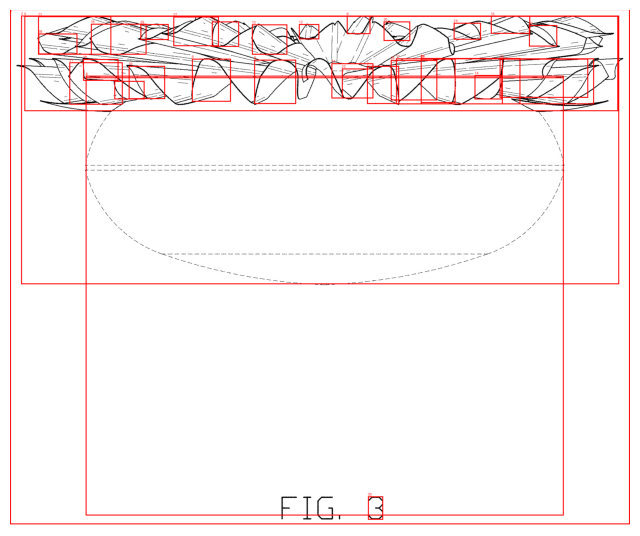

In [22]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import os

row = test_df.iloc[0]

# first image path
img_path = row["crop_paths"][0]

# FIG id, e.g. FIG_3
fig_id = get_fig_id(img_path)

# get regions for this figure
regions = row["regions"][fig_id]

# open image
img = Image.open(img_path).convert("RGB")
draw = ImageDraw.Draw(img)

# draw bounding boxes
for region in regions:
    x1, y1, x2, y2 = region["bbox"]

    draw.rectangle(
        (x1, y1, x2, y2),
        outline="red",
        width=3
    )

    draw.text(
        (x1, max(0, y1 - 12)),
        str(region["id"]),
        fill="red"
    )

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()